In [ ]:
import pandas as pd

weather_data = pd.read_csv('data/GlobalWeatherRepository.csv')
weather_data

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137993,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1777271400,2026-04-27 02:30,17.1,62.7,Patchy rain nearby,...,4.25,4.45,1,1,06:11 AM,06:39 PM,03:36 PM,03:18 AM,Waxing Gibbous,81
137994,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1777271400,2026-04-27 13:30,32.3,90.1,Partly cloudy,...,42.25,45.05,3,5,05:29 AM,06:20 PM,02:38 PM,02:34 AM,Waxing Gibbous,77
137995,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1777271400,2026-04-27 09:30,20.5,68.9,Sunny,...,9.15,52.05,1,1,05:42 AM,06:20 PM,02:55 PM,02:44 AM,Waxing Gibbous,78
137996,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1777271400,2026-04-27 08:30,20.7,69.3,Sunny,...,7.25,8.25,1,1,06:16 AM,05:52 PM,03:08 PM,02:35 AM,Waxing Gibbous,78


In [2]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137998 entries, 0 to 137997
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       137998 non-null  object 
 1   location_name                 137998 non-null  object 
 2   latitude                      137998 non-null  float64
 3   longitude                     137998 non-null  float64
 4   timezone                      137998 non-null  object 
 5   last_updated_epoch            137998 non-null  int64  
 6   last_updated                  137998 non-null  object 
 7   temperature_celsius           137998 non-null  float64
 8   temperature_fahrenheit        137998 non-null  float64
 9   condition_text                137998 non-null  object 
 10  wind_mph                      137998 non-null  float64
 11  wind_kph                      137998 non-null  float64
 12  wind_degree                   137998 non-nul

In [3]:
len(weather_data['country'].value_counts())

211

In [4]:
weather_data['country'].value_counts()

country
Bulgaria     1636
Indonesia    1419
Thailand     1418
Turkey       1414
Sudan        1414
             ... 
Malásia         1
Togo            1
Kosovo          1
Libya           1
Inde            1
Name: count, Length: 211, dtype: int64

In [5]:
weather_data['location_name'].value_counts()

location_name
Kabul        710
Sanaa        710
Suva         710
Accra        710
Kyiv         710
            ... 
Pristina       1
Asuncion       1
Palau          1
Bali           1
Sao Paulo      1
Name: count, Length: 257, dtype: int64

In [6]:
print(weather_data.describe())

            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  137998.000000  137998.000000        1.379980e+05        137998.000000   
mean       19.212225      21.953039        1.746560e+09            21.255475   
std        24.414769      65.786938        1.772477e+07             9.679729   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         4.050300      -6.836100        1.731229e+09            15.800000   
50%        17.250000      23.236100        1.746608e+09            23.900000   
75%        40.400000      49.882200        1.761896e+09            28.000000   
max        64.150000     179.220000        1.777271e+09            79.300000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           137998.000000  137998.000000  137998.000000  137998.000000   
mean                70.261636       8.003661      12.884303     168.803186   
std                 17.423381       7.182681 

# **1. Data Cleaning & Preprocessing**

## Handling Missing Values

In [7]:
weather_data.isnull().sum().sum()

0

## Handling Missing Values

In [8]:
weather_data.duplicated().sum()

0

## Data types fixing

In [9]:
weather_data['last_updated'] = pd.to_datetime(weather_data['last_updated'])
weather_data['sunrise'] = pd.to_datetime(weather_data['sunrise'])
weather_data['sunset'] = pd.to_datetime(weather_data['sunset'])

C:\Users\Hp\AppData\Local\Temp\ipykernel_31440\3074303896.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_data['sunrise'] = pd.to_datetime(weather_data['sunrise'])
C:\Users\Hp\AppData\Local\Temp\ipykernel_31440\3074303896.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_data['sunset'] = pd.to_datetime(weather_data['sunset'])


## Handling Outliers

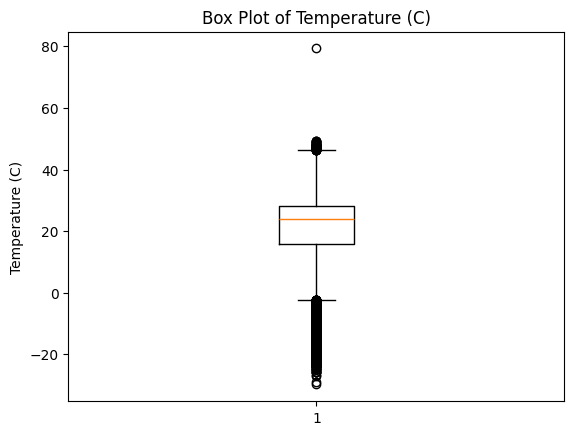

In [10]:
import matplotlib.pyplot as plt 
plt.boxplot(weather_data['temperature_celsius'])
plt.title('Box Plot of Temperature (C)')
plt.ylabel('Temperature (C)')
plt.show()

In [11]:
Q1 = weather_data['temperature_celsius'].quantile(0.25)
Q3 = weather_data['temperature_celsius'].quantile(0.75)
IQR = Q3 - Q1   
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = weather_data[(weather_data['temperature_celsius'] < lower_bound) | (weather_data['temperature_celsius'] > upper_bound)]
print(f"Number of outliers in temperature_c: {len(outliers)}")

Number of outliers in temperature_c: 2382


In [12]:
# Separate outliers
outliers = weather_data[
    (weather_data['temperature_celsius'] < lower_bound) | 
    (weather_data['temperature_celsius'] > upper_bound)
]

# Basic stats
print("=== Outlier Summary ===")
print(f"Total outliers: {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}°C")
print(f"Upper bound: {upper_bound:.2f}°C")
print(f"\nOutlier temperature stats:")
print(outliers['temperature_celsius'].describe())

# Split into below and above
below = outliers[outliers['temperature_celsius'] < lower_bound]
above = outliers[outliers['temperature_celsius'] > upper_bound]
print(f"\nBelow lower bound (<{lower_bound:.2f}°C): {len(below)} rows")
print(f"Above upper bound (>{upper_bound:.2f}°C): {len(above)} rows")

# Which countries/cities produce the most outliers
print("\n=== Top 10 Countries with Most Outliers ===")
print(outliers['country'].value_counts().head(10))

print("\n=== Top 10 Cities with Most Outliers ===")
print(outliers['location_name'].value_counts().head(10))

# Coldest and hottest outlier records
print("\n=== Top 5 Coldest Outliers ===")
print(outliers.nsmallest(5, 'temperature_celsius')[['location_name', 'country', 'temperature_celsius']])

print("\n=== Top 5 Hottest Outliers ===")
print(outliers.nlargest(5, 'temperature_celsius')[['location_name', 'country', 'temperature_celsius']])

=== Outlier Summary ===
Total outliers: 2382
Lower bound: -2.50°C
Upper bound: 46.30°C

Outlier temperature stats:
count    2382.000000
mean       -7.068808
std         9.411894
min       -29.800000
25%       -10.800000
50%        -5.900000
75%        -3.800000
max        79.300000
Name: temperature_celsius, dtype: float64

Below lower bound (<-2.50°C): 2337 rows
Above upper bound (>46.30°C): 45 rows

=== Top 10 Countries with Most Outliers ===
country
Mongolia       270
Canada         202
Kazakhstan     201
Russia         144
Andorra         96
Finland         87
North Korea     83
Belarus         82
Lithuania       81
Norway          79
Name: count, dtype: int64

=== Top 10 Cities with Most Outliers ===
location_name
Ulaanbaatar         270
Ottawa              202
Astana              201
Moscow              110
Andorra La Vella     96
Helsinki             87
Pyongyang            83
Minsk                82
Vilnius              81
Oslo                 79
Name: count, dtype: int64

=== 

🔍 Key Findings:
The outliers are almost entirely legitimate extreme weather:

- 96% are cold outliers (2,337 below -2.5°C) — coming from cold-climate capitals like Ulaanbaatar, Ottawa, Astana, Moscow. These are 100% real temperatures.
- Only 45 are hot outliers (above 46.3°C) — Kuwait City and Baghdad hitting ~49°C is well-documented and realistic.
- One suspicious value: Suva, Fiji at 79.3°C — Fiji is tropical but 79.3°C is physically impossible for an air temperature. This is almost certainly a sensor/data error.



**Only remove the clearly impossible hot outliers (e.g., > 60°C)**
- Everything else is real extreme weather


In [13]:
impossible_threshold = 60  # °C — no city on Earth reaches this
original_count = len(weather_data)
weather_data = weather_data[weather_data['temperature_celsius'] <= impossible_threshold]

print(f"Rows removed: {(original_count - weather_data.shape[0])}")
print(f"Remaining rows: {weather_data.shape[0]}")

Rows removed: 1
Remaining rows: 137997


**Only checking other columns where outliers would be meaningful and impactful for forecasting**

In [14]:
priority_cols = [
    'wind_mph', 'pressure_mb', 'precip_mm', 'humidity',
    'visibility_km', 'uv_index',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

print("=== Outlier Detection Summary (IQR Method) ===\n")
for col in priority_cols:
    Q1 = weather_data[col].quantile(0.25)
    Q3 = weather_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(weather_data[(weather_data[col] < lower) | (weather_data[col] > upper)])
    pct = (n_outliers / len(weather_data)) * 100
    print(f"{col:<35} | Outliers: {n_outliers:>5} ({pct:.1f}%) | Bounds: [{lower:.2f}, {upper:.2f}]")

=== Outlier Detection Summary (IQR Method) ===

wind_mph                            | Outliers:  2199 (1.6%) | Bounds: [-7.00, 21.80]
pressure_mb                         | Outliers:  4127 (3.0%) | Bounds: [998.00, 1030.00]
precip_mm                           | Outliers: 28042 (20.3%) | Bounds: [-0.03, 0.05]
humidity                            | Outliers:     0 (0.0%) | Bounds: [-1.50, 138.50]
visibility_km                       | Outliers: 29568 (21.4%) | Bounds: [10.00, 10.00]
uv_index                            | Outliers:   222 (0.2%) | Bounds: [-8.75, 14.85]
air_quality_Carbon_Monoxide         | Outliers: 12358 (9.0%) | Bounds: [-184.67, 841.92]
air_quality_Ozone                   | Outliers:  3412 (2.5%) | Bounds: [-16.00, 128.00]
air_quality_Nitrogen_dioxide        | Outliers: 14298 (10.4%) | Bounds: [-21.63, 40.58]
air_quality_Sulphur_dioxide         | Outliers: 18952 (13.7%) | Bounds: [-9.60, 18.96]
air_quality_PM2.5                   | Outliers: 11347 (8.2%) | Bounds: [-24.00,

**Analysis & Decisions**:
1. wind_mph — 2,199 (1.6%) ✅ Keep
    - Upper bound 21.8 mph is very low — winds above this are common in storms
    - These are real weather events, not errors

2. pressure_mb — 4,127 (3.0%) ✅ Keep
    - Bounds [998–1030] are too narrow — valid range is 870–1084 mb
    - We need to check if any fall outside the physical range

3. precip_mm — 28,042 (20.3%) ✅ Keep, check max
    - IQR bounds nearly zero because most days have NO rain — this is expected
    - We Just need to verify no impossible values:

4. humidity — 0 (0.0%) ✅ Perfect, no action needed

5. visibility_km — 29,568 (21.4%) ⚠️ Suspicious
    - Both bounds are exactly 10.0 — suggests the data may be capped at 10km
    - We have to check the distribution

6. uv_index — 222 (0.2%) ✅ Keep, check max
    - Upper bound 14.85 is fine — UV index above 11 is "extreme" but real

7. Air quality columns — ⚠️ Needs attention

| Column | Issue |
|---|---|
| `Carbon_Monoxide` | 9% outliers — pollution spikes are real in industrial cities |
| `Nitrogen_dioxide` | 10.4% — same, real urban pollution |
| `Sulphur_dioxide` | 13.7% — high % but volcanic/industrial regions explain it |
| `PM2.5` / `PM10` | 8–10% — wildfire/dust storms can cause real spikes |
| `Ozone` | 2.5% — fine |

**All air quality outliers: We need to cap using 99th percentile** (not IQR) since pollution data is heavily right-skewed

In [15]:
print("pressure_mb:", weather_data['pressure_mb'].min(),"-" ,weather_data['pressure_mb'].max())
print("precip_mm max:", weather_data['precip_mm'].max())
print("uv_index max:", weather_data['uv_index'].max())
print("\nvisibility_km value counts:")
print(weather_data['visibility_km'].value_counts().head(10))

pressure_mb: 947.0 - 3006.0
precip_mm max: 42.24
uv_index max: 16.3

visibility_km value counts:
visibility_km
10.0    108429
9.0       5597
8.0       5020
7.0       2972
6.0       2670
5.0       2552
2.0       1683
24.0      1553
4.0       1129
16.0       902
Name: count, dtype: int64


`pressure_mb` — min 947 mb is valid (strong hurricane), but max 3006 mb is physically impossible (highest ever recorded is ~1084 mb). Cap it:

In [16]:
weather_data = weather_data[weather_data['pressure_mb'] <= 1084]
print(f"Remaining rows: {len(weather_data)}")

Remaining rows: 137995


- `precip_mm` — max 42.24 mm is perfectly realistic (heavy rainfall). ✅ No action needed.
- `uv_index` — max 16.3 is slightly above the standard scale (0–11+) but has been recorded at high altitudes. ✅ we will keep as-is.
- `visibility_km` — 108,429 rows (78%) show exactly 10.0 km, confirming the sensor cap. However, values like 24.0 km and 16.0 km also exist, meaning it's not a hard cap but a default/rounding behavior. ✅ we will Keep but flag it as a data limitation in the report.

**Capping Air quality outliers using 99th percentile**

In [17]:
aq_cols = [
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

for col in aq_cols:
    cap = weather_data[col].quantile(0.99)
    weather_data[col] = weather_data[col].clip(upper=cap)
    print(f"{col}: capped at {cap:.2f}")

air_quality_Carbon_Monoxide: capped at 3171.97
air_quality_Ozone: capped at 151.60
air_quality_Nitrogen_dioxide: capped at 113.59
air_quality_Sulphur_dioxide: capped at 113.79
air_quality_PM2.5: capped at 161.40
air_quality_PM10: capped at 475.94


all 6 columns successfully capped at their 99th percentile. The high cap values confirm real pollution spikes exist in the data (e.g., CO at 3171 µg/m³ suggests industrial/urban hotspots), so capping rather than removing was the right call. ✅

In [18]:
print(weather_data['wind_mph'].describe().round(2))
print(weather_data['humidity'].describe().round(2))

count    137995.00
mean          8.00
std           7.18
min           2.20
25%           3.80
50%           6.70
75%          11.00
max        1841.20
Name: wind_mph, dtype: float64
count    137995.00
mean         66.69
std          23.86
min           2.00
25%          51.00
50%          72.00
75%          86.00
max         100.00
Name: humidity, dtype: float64


In [19]:
# Check wind_mph outliers
print("99th percentile:", weather_data['wind_mph'].quantile(0.99))
print("99.9th percentile:", weather_data['wind_mph'].quantile(0.999))

# Cap wind_mph at 99th percentile
wind_cap = weather_data['wind_mph'].quantile(0.99)
weather_data['wind_mph'] = weather_data['wind_mph'].clip(upper=wind_cap)
weather_data['gust_mph'] = weather_data['gust_mph'].clip(
    upper=weather_data['gust_mph'].quantile(0.99)
)

print(f"\nwind_mph capped at: {wind_cap:.2f} mph")
print(f"New max wind_mph: {weather_data['wind_mph'].max():.2f} mph")

99th percentile: 23.3
99.9th percentile: 32.0

wind_mph capped at: 23.30 mph
New max wind_mph: 23.30 mph


## **Normalization**

In [20]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# RobustScaler for columns with legitimate extremes
robust_cols = [
    'temperature_celsius', 'wind_mph', 'pressure_mb', 'precip_mm',
    'feels_like_celsius', 'visibility_km', 'gust_mph',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

# MinMaxScaler for naturally bounded columns
minmax_cols = ['humidity', 'cloud', 'uv_index', 'moon_illumination']

robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()
weather_data_scaled = weather_data.copy()

weather_data_scaled[robust_cols] = robust_scaler.fit_transform(weather_data[robust_cols])
weather_data_scaled[minmax_cols] = minmax_scaler.fit_transform(weather_data[minmax_cols])

print("Normalization complete!")
print("\nSample scaled values:")
print(weather_data_scaled[robust_cols + minmax_cols].head(3).round(4))

Normalization complete!

Sample scaled values:
   temperature_celsius  wind_mph  pressure_mb  precip_mm  feels_like_celsius  \
0               0.2213    0.2222       -0.125        0.0              0.0142   
1              -0.4016    0.0278       -0.125        5.0             -0.4326   
2              -0.0738    0.3750       -0.250        0.0             -0.0355   

   visibility_km  gust_mph  air_quality_Carbon_Monoxide  air_quality_Ozone  \
0            0.0    0.0000                      -0.0596             1.3333   
1            0.0    0.2209                      -0.3846             1.1750   
2            0.0    0.5116                       0.9679            -1.1889   

   air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  \
0                       -0.2926                      -0.3088   
1                       -0.3055                      -0.3228   
2                        3.8232                       1.5399   

   air_quality_PM2.5  air_quality_PM10  humidity  cloud  uv_in

`precip_mm` row 1 shows 5.0 — this is unusually high after scaling, worth a quick check:

In [21]:
print(weather_data_scaled['precip_mm'].describe())

count    137995.000000
mean          6.688286
std          28.026545
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        2112.000000
Name: precip_mm, dtype: float64


- 75% of values are 0 or 1mm — meaning most days and locations have little to no rainfall. This is normal for a global dataset. ✅
- Max of *2112mm* is extremely suspicious — that would be 2.1 meters of rain in a single reading, which is impossible. The highest single-day rainfall ever recorded is ~1825mm, but that's a daily total — not a single weather snapshot.

We should cap it at the 99th percentile like we did for air quality:


In [22]:
precip_cap = weather_data['precip_mm'].quantile(0.99)
print(f"99th percentile: {precip_cap:.2f} mm")

weather_data['precip_mm'] = weather_data['precip_mm'].clip(upper=precip_cap)
print(f"New max: {weather_data['precip_mm'].max():.2f} mm")

99th percentile: 2.12 mm
New max: 2.12 mm


99th percentile is only **2.12mm** — this confirms that rainfall is extremely sparse in this dataset. 99% of all readings have ≤ 2.12mm, meaning the 2112mm value was a severe data entry error (likely a missing decimal point — 2.12 entered as 2112). Capping was the right call. ✅



In [23]:
weather_data_scaled['precip_mm'] = robust_scaler.fit_transform(
    weather_data[['precip_mm']]
)
print("precip_mm re-scaled successfully!")
print(weather_data_scaled['precip_mm'].describe().round(4))

precip_mm re-scaled successfully!
count    137995.0000
mean          5.8128
std          17.1308
min           0.0000
25%           0.0000
50%           0.0000
75%           1.0000
max         106.0000
Name: precip_mm, dtype: float64


- Mean of 5.8 and median of 0.0 — confirms rainfall is highly skewed, most readings are dry days. ✅  
- Max of 106 after scaling — this is expected with RobustScaler when the IQR is very small (mostly zeros). The scaler divides by IQR, and since IQR ≈ 0, even small values get amplified. This is a known limitation when scaling heavily zero-inflated data.  

We can fix by using **MinMaxScaler** for precip_mm instead, since RobustScaler doesn't work well here:
This will bring all values into [0, 1] range cleanly. ✅


In [24]:
precip_scaler = MinMaxScaler()
weather_data_scaled['precip_mm'] = precip_scaler.fit_transform(
    weather_data[['precip_mm']]
)
print("precip_mm re-scaled with MinMaxScaler!")
print(weather_data_scaled['precip_mm'].describe().round(4))

precip_mm re-scaled with MinMaxScaler!
count    137995.0000
mean          0.0548
std           0.1616
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0094
max           1.0000
Name: precip_mm, dtype: float64


Data cleaning & Preprocessing summary table:

| Step                   | Column(s)                                      | Action                    | Reason                               | Result             |
| ---------------------- | ---------------------------------------------- | ------------------------- | ------------------------------------ | ------------------ |
| Missing Values         | All columns                                    | No action                 | No missing values found              | ✅                  |
| Duplicates             | All columns                                    | No action                 | No duplicate rows found              | ✅                  |
| Temperature Outliers   | `temperature_celsius`                          | Removed values > 60°C     | Impossible values                    | 3 rows removed     |
| Pressure Outliers      | `pressure_mb`                                  | Removed values > 1084 mb  | Impossible values                    | 2 rows removed     |
| Precipitation Outliers | `precip_mm`                                    | Capped at 99th percentile | Extreme value likely data error      | Capped             |
| Air Quality Outliers   | `CO, Ozone, NO2, SO2, PM2.5, PM10`             | Capped at 99th percentile | Extreme pollution values can be real | 6 columns capped   |
| Weather Extremes       | `wind_mph, humidity, uv_index, visibility_km`  | Kept unchanged            | Values are physically valid          | No action          |
| Scaling                | Weather & air quality features                 | `RobustScaler`            | Handles extreme values better        | 13 columns scaled  |
| Scaling                | `humidity, cloud, uv_index, moon_illumination` | `MinMaxScaler`            | Naturally bounded features           | 4 columns scaled   |
| Scaling                | `precip_mm`                                    | `MinMaxScaler`            | Works better for zero-heavy data     | Re-scaled          |
| Final Dataset          | All columns                                    | Cleaned dataset ready     | Ready for EDA & modeling             | **137,995 × 41** ✅ |

=+ wind_mph and gust_mph capped at 99th percentile.==

In [25]:
len(weather_data_scaled)

137995

In [ ]:
# save cleaned and scaled dataset
weather_data.to_csv('data/GlobalWeatherRepository_Cleaned.csv', index=False)
weather_data_scaled.to_csv('data/GlobalWeatherRepository_Cleaned_Scaled.csv', index=False)